In [1]:
import time
import matplotlib.pyplot as plt
import datetime
from qcodes.parameters import MultiParameter
import numpy as np
from qcodes import Parameter
import sys
from time import sleep
import pyvisa
from qcodes.dataset import Measurement
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
initialise_or_create_database_at("./2026-03-10_SNSPD4.db")

from time import sleep, monotonic

# Set up experiment
exp_name = 'SNSPD4_23_03_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 47


# Device names

In [3]:
device_name_1 = 'Line 1 R7C6'
device_name_2 = 'Line 2 Old Device'

Text(0, 0.5, 'Ratio V/I')

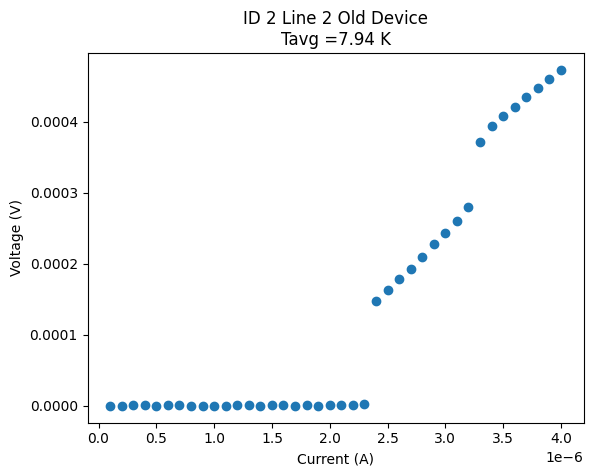

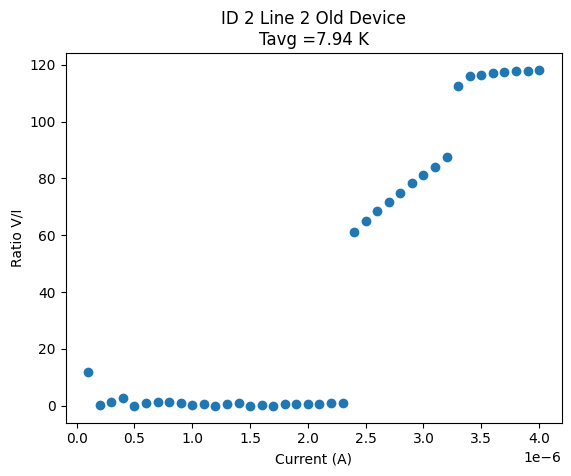

In [5]:
ID = 2
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID} {device_name_2}\nTavg ={t_avg:.2f} K')
plt.xlabel('Current (A)')
plt.ylabel('Voltage (V)')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID} {device_name_2}\nTavg ={t_avg:.2f} K')
plt.xlabel('Current (A)')
plt.ylabel('Ratio V/I')

Text(0, 0.5, 'Ratio V/I')

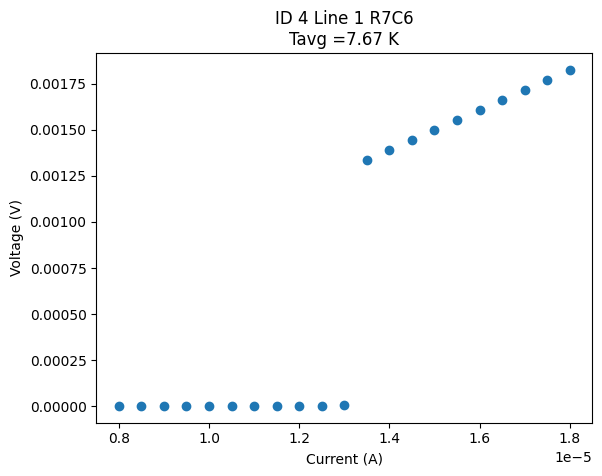

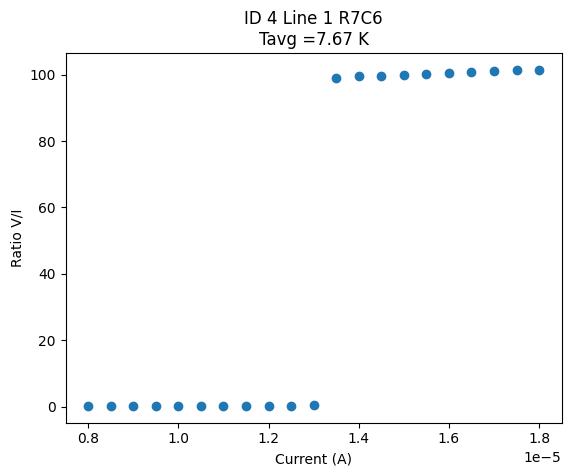

In [6]:
ID = 4
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])

plt.plot(current, voltage, 'o')
plt.title(f'ID {ID} {device_name_1}\nTavg ={t_avg:.2f} K')
plt.xlabel('Current (A)')
plt.ylabel('Voltage (V)')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID} {device_name_1}\nTavg ={t_avg:.2f} K')
plt.xlabel('Current (A)')
plt.ylabel('Ratio V/I')

Text(0, 0.5, 'V')

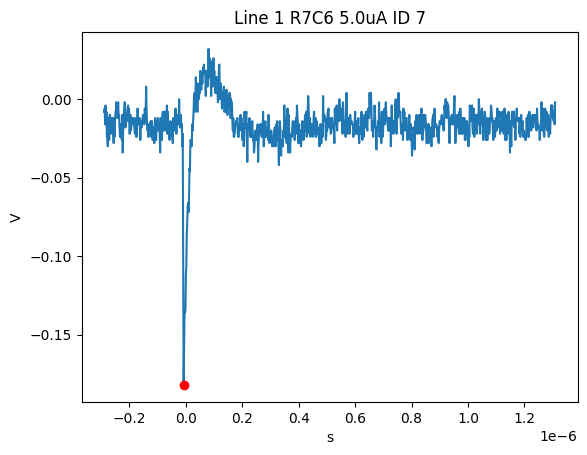

In [7]:
ID = 7

data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']

peak = np.where(trace == min(trace))

plt.plot(time_axis, trace)
plt.plot(time_axis[peak], trace[peak], 'ro')
plt.title(f'{device_name_1} {current*1e6}uA ID {ID}')
plt.xlabel('s')
plt.ylabel('V')

Text(0.5, 0, 'Current ($\\mu$A)')

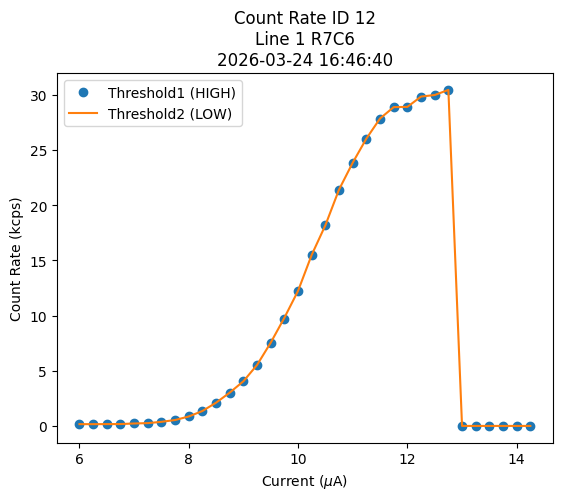

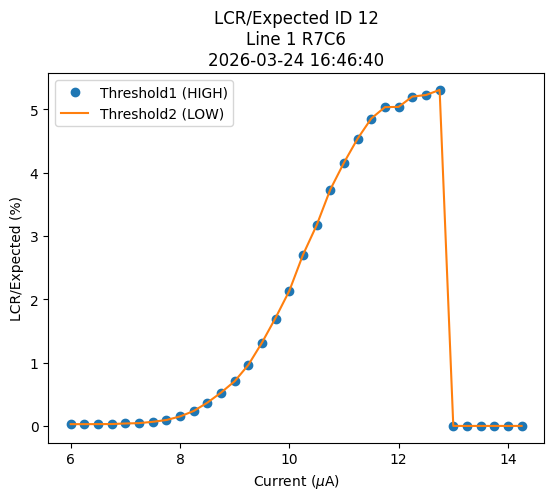

In [35]:
ID = 12 

data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
timestamp = load_by_id(ID).run_timestamp()
device = device_name_1


plt.title(f'Count Rate ID {ID}\n{device}\n{timestamp}')
plt.plot(current*1e6, CR1*1e-3, 'o')
plt.plot(current*1e6, CR2*1e-3)
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (kcps)')
plt.xlabel(r'Current ($\mu$A)')

plt.figure()
Nphotons_fiber2 = 573467.1443081173
plt.title(f'LCR/Expected ID {ID}\n{device}\n{timestamp}')
plt.plot(current*1e6, 100*CR1/Nphotons_fiber2, 'o')
plt.plot(current*1e6, 100*CR2/Nphotons_fiber2)
plt.ylabel('LCR/Expected (%)')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.xlabel(r'Current ($\mu$A)')

# plt.figure()
# plt.title(f'Critical Current\n{device}\n{timestamp}')
# plt.plot(current, voltage*1e3, '.')
# plt.ylabel('Voltage (mV)')
# plt.xlabel('Current(A)')


In [188]:
data = load_by_id(12).get_parameter_data()
current = data['yoko_current']['yoko_current']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
Nphotons_fiber2 = 573467.1443081173
SDE1_perc = 100*CR1/Nphotons_fiber2
SDE2_perc = 100*CR2/Nphotons_fiber2
SDE_12uA_5Vappplied = SDE1_perc[np.where(np.array(current) == 12e-6)[0][0]]
print(f'SDE at 12uA is {SDE_12uA_5Vappplied}')

SDE at 12uA is 5.037952173722649


Text(0.5, 0, 'Voltage Applied to VOA1550PA (V)')

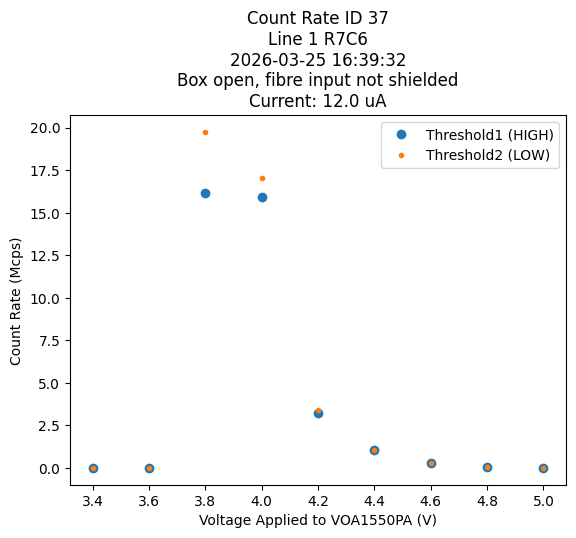

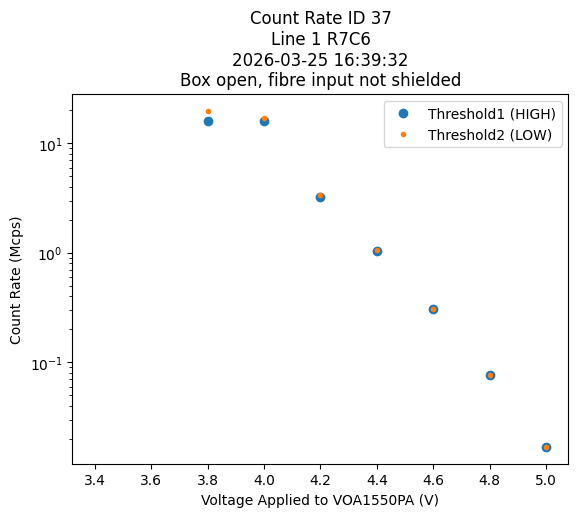

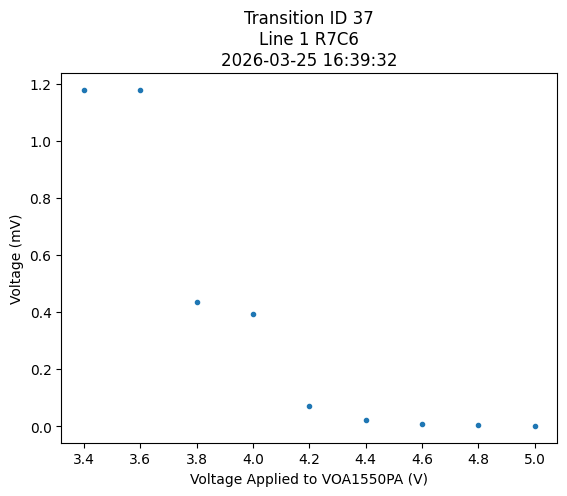

In [162]:

data = load_by_id(12).get_parameter_data()
current = data['yoko_current']['yoko_current']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
Nphotons_fiber2 = 573467.1443081173
SDE1_perc = 100*CR1/Nphotons_fiber2
SDE2_perc = 100*CR2/Nphotons_fiber2
SDE_12uA_5Vappplied = SDE1_perc[np.where(np.array(current) == 12e-6)[0][0]]
print(f'SDE at 12uA is {SDE_12uA_5Vappplied}')

ID = 37

data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
v_attenuator = data['v_attenuator']['v_attenuator']
timestamp = load_by_id(ID).run_timestamp()
device = device_name_1

plt.title(f'Count Rate ID {ID}\n{device}\n{timestamp}\n{conditions}\nCurrent: {current[0]*1e6} uA')
plt.plot(v_attenuator, CR1*1e-6, 'o')
plt.plot(v_attenuator, CR2*1e-6, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (Mcps)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')
plt.plot(5, SDE_12uA_5Vappplied, 'ro', label='5V attenuation from ID 12 sweep')

plt.figure()
plt.title(f'Count Rate ID {ID}\n{device}\n{timestamp}\n{conditions}')
plt.semilogy(v_attenuator, CR1*1e-6, 'o')
plt.semilogy(v_attenuator, CR2*1e-6, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (Mcps)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')


plt.figure()
plt.title(f'Transition ID {ID}\n{device}\n{timestamp}')
plt.plot(v_attenuator, voltage*1e3, '.')
plt.ylabel('Voltage (mV)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')

# 30/3/26

Text(0.5, 0, 'Current ($\\mu$A)')

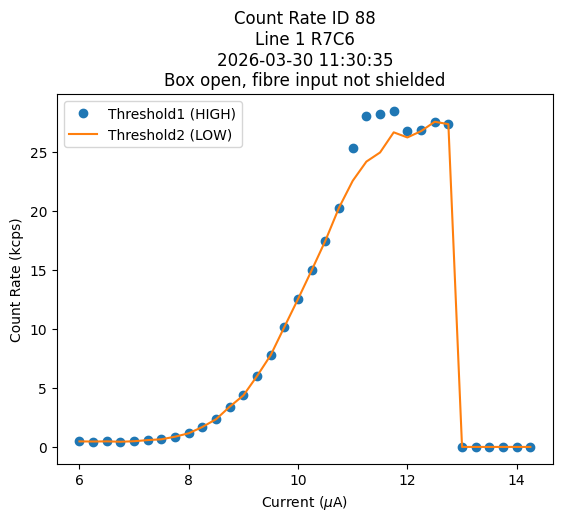

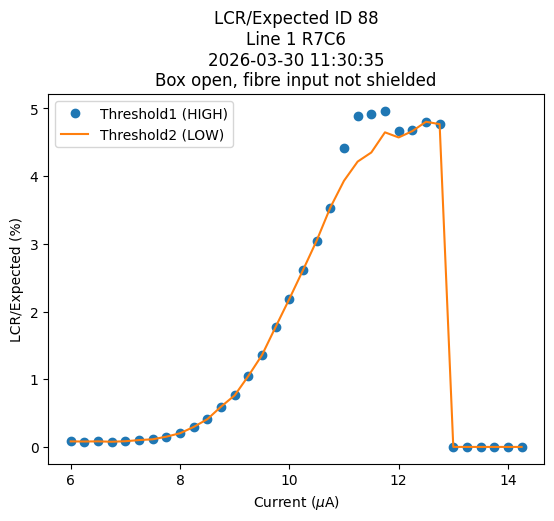

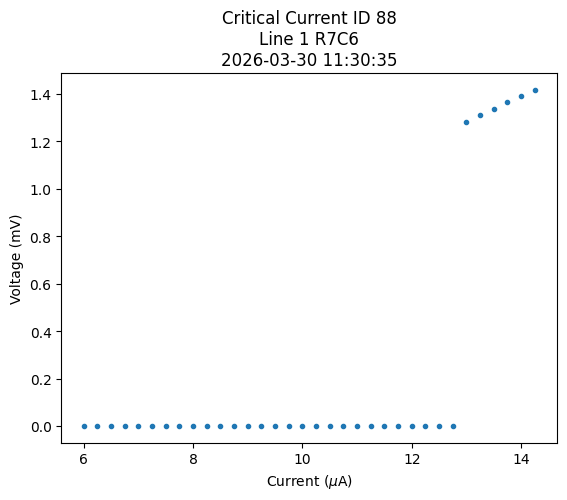

In [33]:
ID = 88 

data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
v_attenuator = data['v_attenuator']['v_attenuator']
timestamp = load_by_id(ID).run_timestamp()
device = load_by_id(ID).metadata['device']
conditions = 'Box open, fibre input not shielded'

plt.title(f'Count Rate ID {ID}\n{device}\n{timestamp}\n{conditions}')
plt.plot(current*1e6, CR1*1e-3, 'o')
plt.plot(current*1e6, CR2*1e-3)
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (kcps)')
plt.xlabel(r'Current ($\mu$A)')

plt.figure()
Nphotons_fiber2 = 573467.1443081173
plt.title(f'LCR/Expected ID {ID}\n{device}\n{timestamp}\n{conditions}')
plt.plot(current*1e6, 100*CR1/Nphotons_fiber2, 'o')
plt.plot(current*1e6, 100*CR2/Nphotons_fiber2)
plt.ylabel('LCR/Expected (%)')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.xlabel(r'Current ($\mu$A)')

plt.figure()
plt.title(f'Critical Current ID {ID}\n{device}\n{timestamp}')
plt.plot(current*1e6, voltage*1e3, '.')
plt.ylabel('Voltage (mV)')
plt.xlabel(r'Current ($\mu$A)')


In [36]:
v_attenuator

array([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
       5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.])

Text(0.5, 0, 'Current ($\\mu$A)')

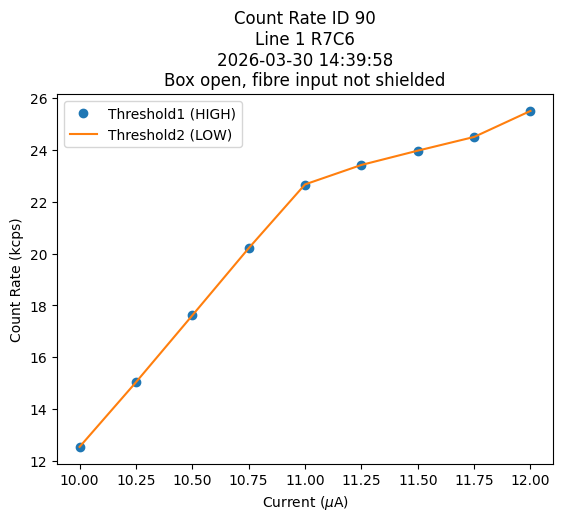

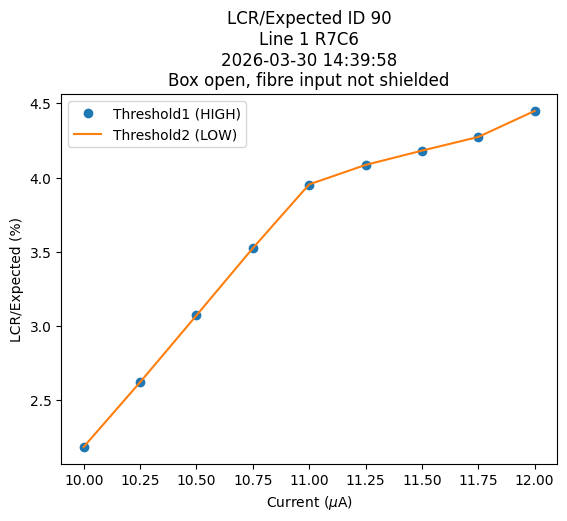

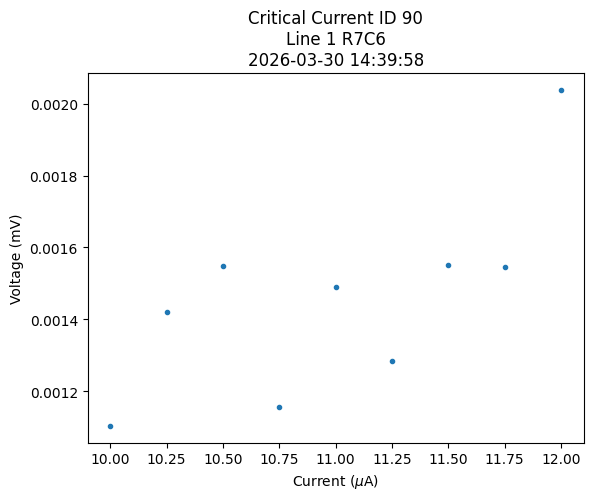

In [37]:
ID = 90

data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
v_attenuator = data['v_attenuator']['v_attenuator']
timestamp = load_by_id(ID).run_timestamp()
device = load_by_id(ID).metadata['device']
conditions = 'Box open, fibre input not shielded'

plt.title(f'Count Rate ID {ID}\n{device}\n{timestamp}\n{conditions}')
plt.plot(current*1e6, CR1*1e-3, 'o')
plt.plot(current*1e6, CR2*1e-3)
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (kcps)')
plt.xlabel(r'Current ($\mu$A)')

plt.figure()
Nphotons_fiber2 = 573467.1443081173
plt.title(f'LCR/Expected ID {ID}\n{device}\n{timestamp}\n{conditions}')
plt.plot(current*1e6, 100*CR1/Nphotons_fiber2, 'o')
plt.plot(current*1e6, 100*CR2/Nphotons_fiber2)
plt.ylabel('LCR/Expected (%)')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.xlabel(r'Current ($\mu$A)')

plt.figure()
plt.title(f'Critical Current ID {ID}\n{device}\n{timestamp}')
plt.plot(current*1e6, voltage*1e3, '.')
plt.ylabel('Voltage (mV)')
plt.xlabel(r'Current ($\mu$A)')


Text(0.5, 0, 'Current ($\\mu$A)')

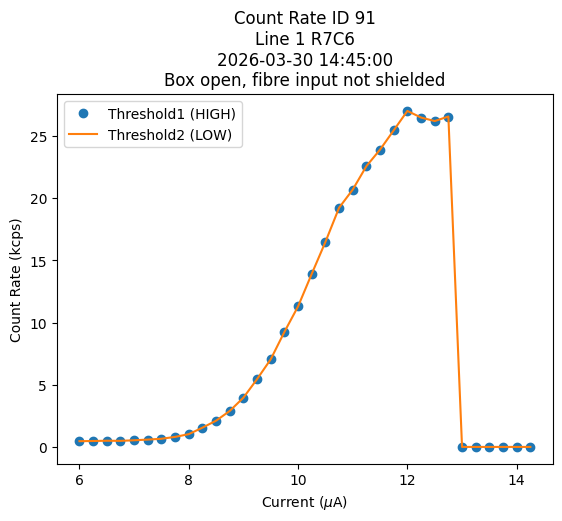

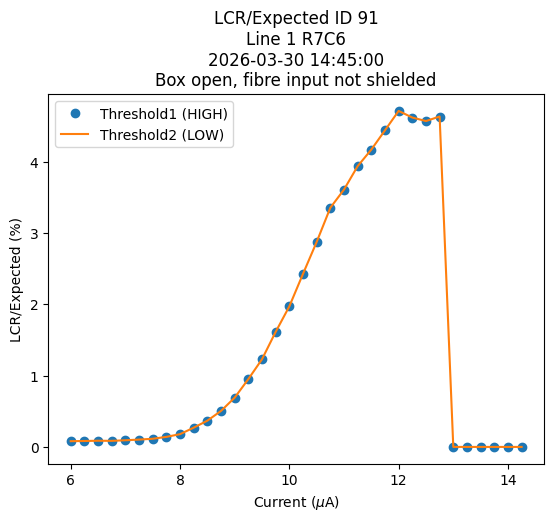

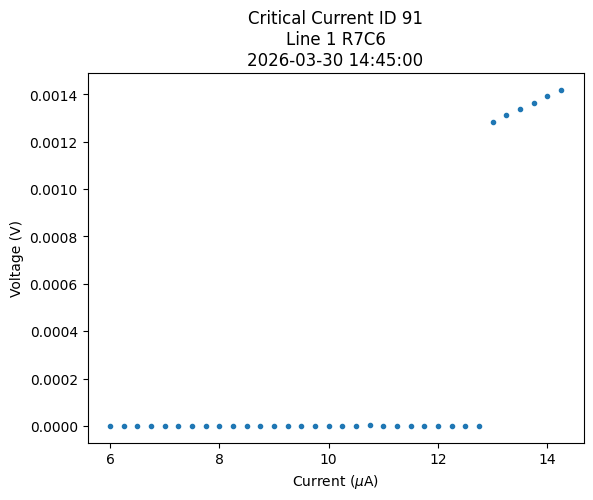

In [43]:
ID = 91

data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
v_attenuator = data['v_attenuator']['v_attenuator']
timestamp = load_by_id(ID).run_timestamp()
device = load_by_id(ID).metadata['device']
conditions = 'Box open, fibre input not shielded'

plt.title(f'Count Rate ID {ID}\n{device}\n{timestamp}\n{conditions}')
plt.plot(current*1e6, CR1*1e-3, 'o')
plt.plot(current*1e6, CR2*1e-3)
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (kcps)')
plt.xlabel(r'Current ($\mu$A)')

plt.figure()
Nphotons_fiber2 = 573467.1443081173
plt.title(f'LCR/Expected ID {ID}\n{device}\n{timestamp}\n{conditions}')
plt.plot(current*1e6, 100*CR1/Nphotons_fiber2, 'o')
plt.plot(current*1e6, 100*CR2/Nphotons_fiber2)
plt.ylabel('LCR/Expected (%)')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.xlabel(r'Current ($\mu$A)')

plt.figure()
plt.title(f'Critical Current ID {ID}\n{device}\n{timestamp}')
plt.plot(current*1e6, voltage, '.')
plt.ylabel('Voltage (V)')
plt.xlabel(r'Current ($\mu$A)')


Text(0.5, 0, 'Voltage Applied to VOA1550PA (V)')

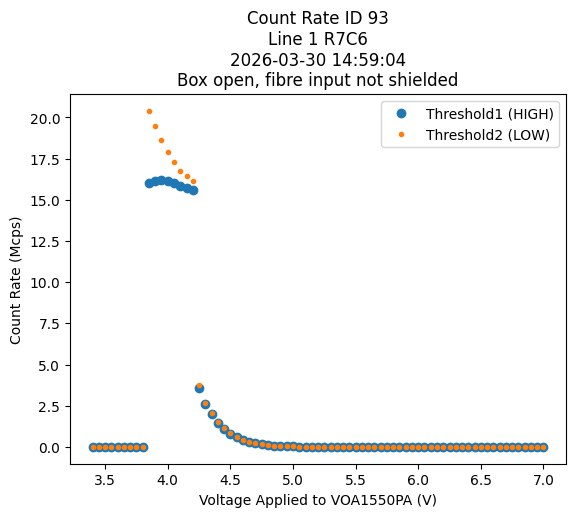

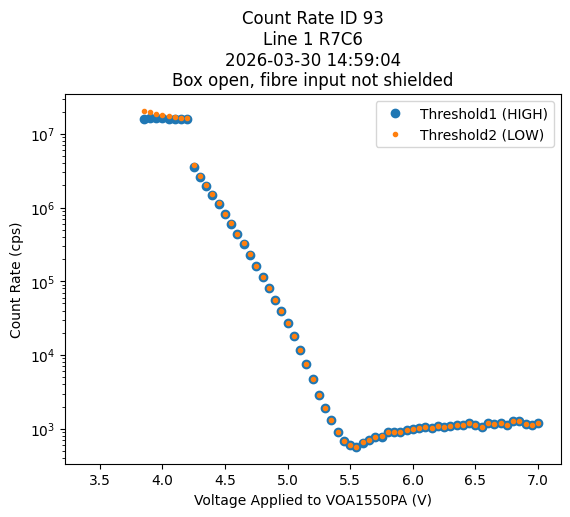

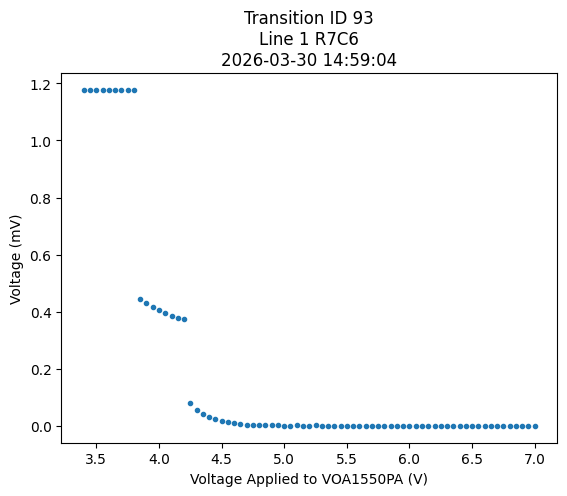

In [56]:
ID = 93

data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
v_attenuator = data['v_attenuator']['v_attenuator']
timestamp = load_by_id(ID).run_timestamp()
device = load_by_id(ID).metadata['device']
conditions = 'Box open, fibre input not shielded'

plt.title(f'Count Rate ID {ID}\n{device}\n{timestamp}\n{conditions}')
plt.plot(v_attenuator, CR1*1e-6, 'o')
plt.plot(v_attenuator, CR2*1e-6, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (Mcps)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')

plt.figure()
plt.title(f'Count Rate ID {ID}\n{device}\n{timestamp}\n{conditions}')
plt.semilogy(v_attenuator, CR1, 'o')
plt.semilogy(v_attenuator, CR2, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (cps)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')


plt.figure()
plt.title(f'Transition ID {ID}\n{device}\n{timestamp}')
plt.plot(v_attenuator, voltage*1e3, '.')
plt.ylabel('Voltage (mV)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')



Text(0, 0.5, 'V')

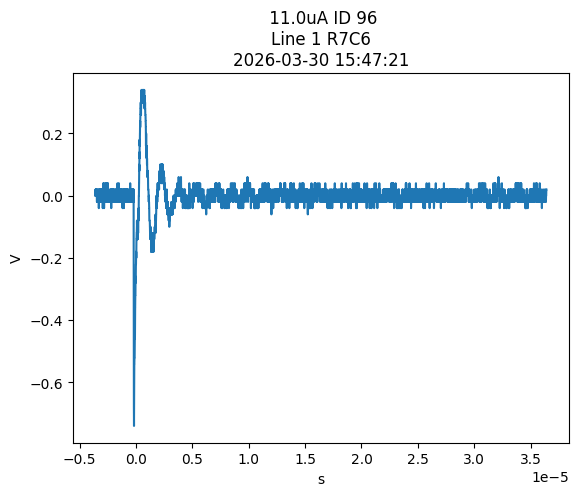

In [153]:
ID = 96
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']
timestamp = load_by_id(ID).run_timestamp()
device = load_by_id(ID).metadata['device']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {ID}\n{device}\n{timestamp}')
plt.xlabel('s')
plt.ylabel('V')

Text(0, 0.5, 'Ratio V/I')

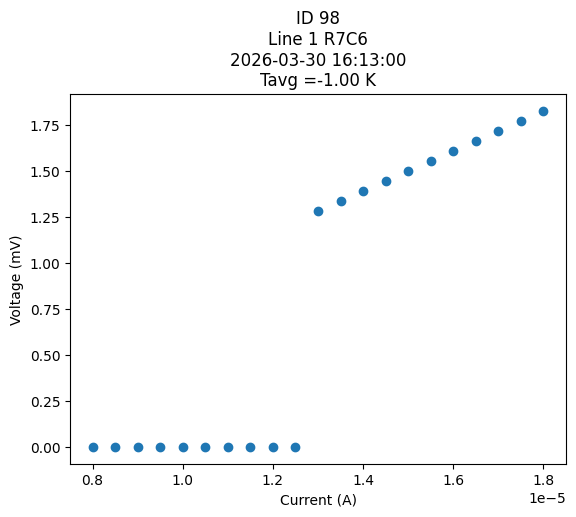

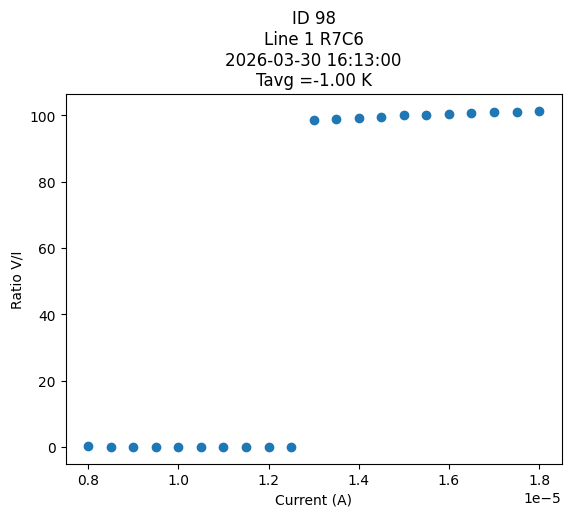

In [61]:
ID = 98
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])
timestamp = load_by_id(ID).run_timestamp()
device = load_by_id(ID).metadata['device']


plt.plot(current, voltage*1e3, 'o')
plt.title(f'ID {ID}\n{device}\n{timestamp}\nTavg ={t_avg:.2f} K')
plt.xlabel('Current (A)')
plt.ylabel('Voltage (mV)')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}\n{device}\n{timestamp}\nTavg ={t_avg:.2f} K')
plt.xlabel('Current (A)')
plt.ylabel('Ratio V/I')

Shows that shunt is still there

Text(0.5, 0, 'Voltage Applied to VOA1550PA (V)')

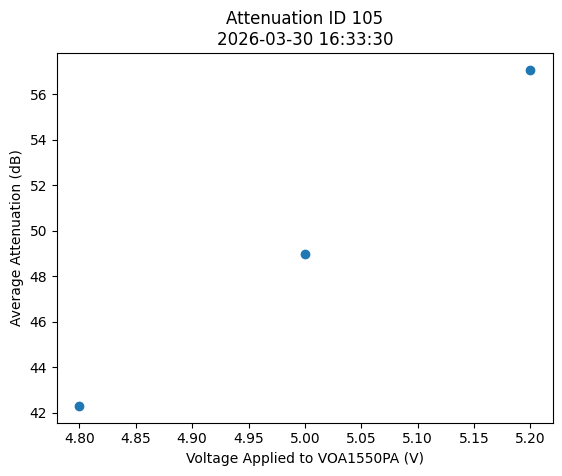

In [68]:
ID = 105

data = load_by_id(ID).get_parameter_data()
v_attenuator = data['v_attenuator']['v_attenuator']
avg_attenuation = data['avg_attenuation']['avg_attenuation']
timestamp = load_by_id(ID).run_timestamp()


plt.title(f'Attenuation ID {ID}\n{timestamp}')
plt.plot(v_attenuator, avg_attenuation, 'o')
plt.ylabel('Average Attenuation (dB)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')



Text(0, 0.5, 'log(Power (W))')

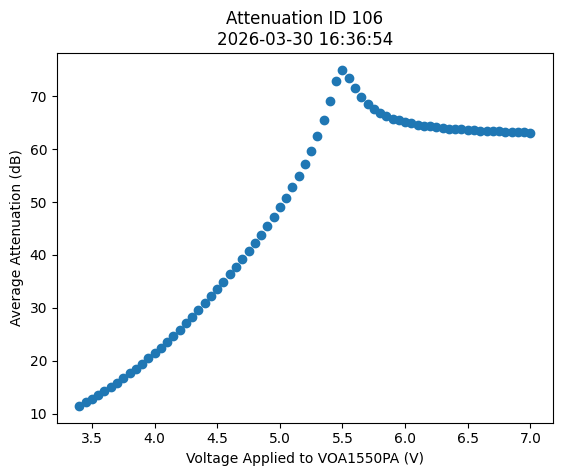

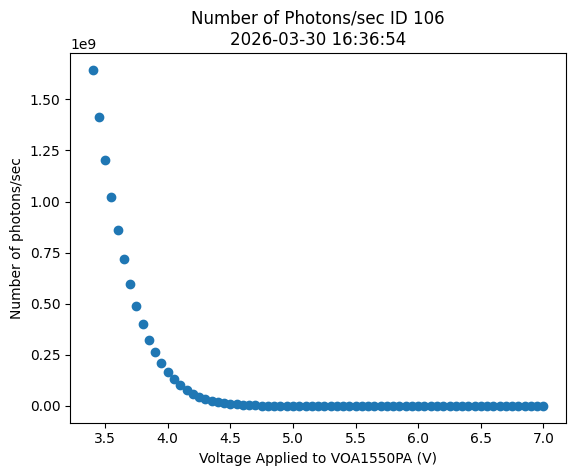

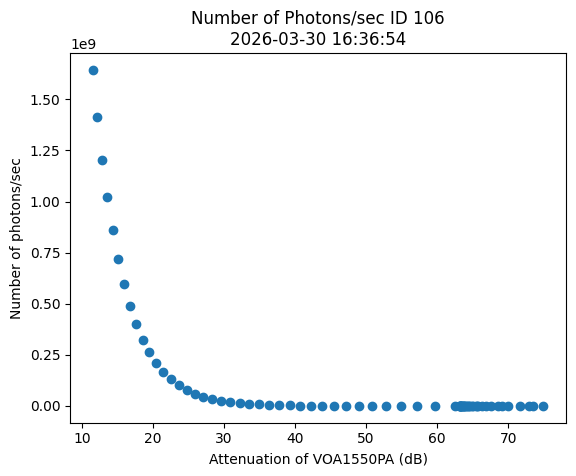

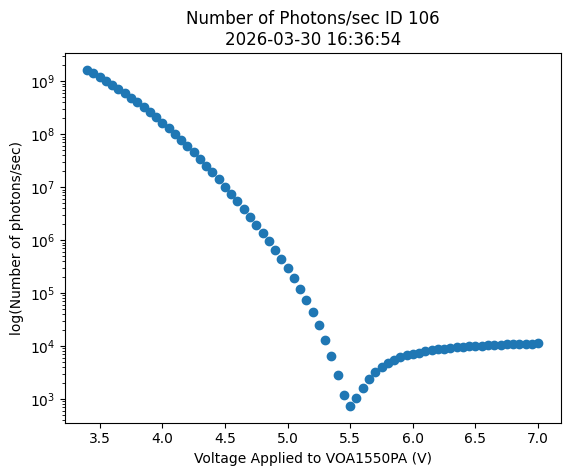

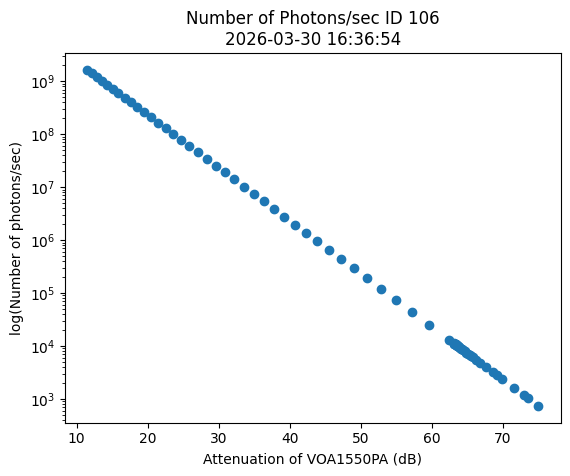

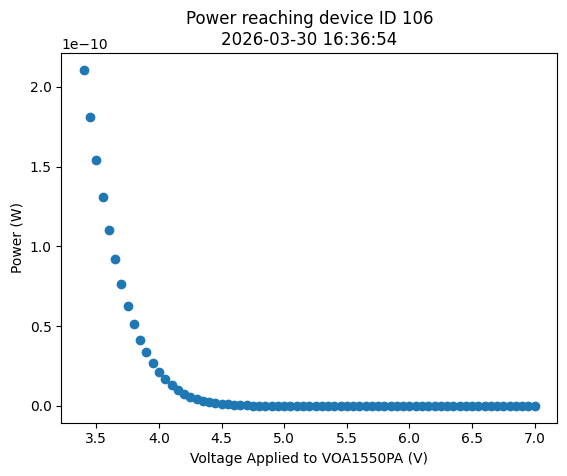

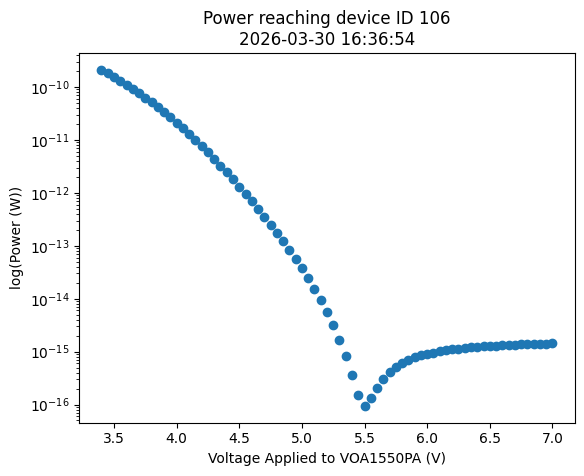

In [178]:
ID = 106

data = load_by_id(ID).get_parameter_data()
v_attenuator = data['v_attenuator']['v_attenuator']
avg_attenuation = data['avg_attenuation']['avg_attenuation']
timestamp = load_by_id(ID).run_timestamp()


plt.title(f'Attenuation ID {ID}\n{timestamp}')
plt.plot(v_attenuator, avg_attenuation, 'o')
plt.ylabel('Average Attenuation (dB)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')


import scipy.constants as spc 
wavelength = 1550e-9 
f = spc.c/wavelength 
Ephoton = spc.h*f

N_photons_ID106 = []
Pdevice_ID106 = []

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265 # From measuremnet 3 beam splitter calibration 

Plaser =  0.00484314281/bs90
# Plaser =  0.0045/bs90 # <- reduce laser power
# Plaser =  0.004/bs90 # <- reduce laser power
Pin = Plaser*bs10 # power reaching attenuators 

for attenuation in avg_attenuation: # go through values measured for average attenuation

    Patt_VOA1550PA = -attenuation
    Patt_VOA50PM_APC = -48.5 # measurement 3 ID 16
    Patt_VOA50PM_APC = -50 # <- increase attenuation
    Patt_VOA50PM_APC = -52 # <- increase attenuation

    total_attenuation_fiber2 = Patt_VOA1550PA + Patt_VOA50PM_APC
    Pdevice = Pin*(10**(total_attenuation_fiber2/10))

    N_photons_ID106.append(Pdevice/Ephoton)
    Pdevice_ID106.append(Pdevice)


plt.figure()
plt.title(f'Number of Photons/sec ID {ID}\n{timestamp}')
plt.plot(v_attenuator, N_photons_ID106, 'o')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')
plt.ylabel('Number of photons/sec')

plt.figure()
plt.title(f'Number of Photons/sec ID {ID}\n{timestamp}')
plt.plot(avg_attenuation, N_photons_ID106, 'o')
plt.xlabel(r'Attenuation of VOA1550PA (dB)')
plt.ylabel('Number of photons/sec')

plt.figure()
plt.title(f'Number of Photons/sec ID {ID}\n{timestamp}')
plt.semilogy(v_attenuator, N_photons_ID106, 'o')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')
plt.ylabel('log(Number of photons/sec)')

plt.figure()
plt.title(f'Number of Photons/sec ID {ID}\n{timestamp}')
plt.semilogy(avg_attenuation, N_photons_ID106, 'o')
plt.xlabel(r'Attenuation of VOA1550PA (dB)')
plt.ylabel('log(Number of photons/sec)')


plt.figure()
plt.title(f'Power reaching device ID {ID}\n{timestamp}')
plt.plot(v_attenuator, Pdevice_ID106, 'o')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')
plt.ylabel('Power (W)')

plt.figure()
plt.title(f'Power reaching device ID {ID}\n{timestamp}')
plt.semilogy(v_attenuator, Pdevice_ID106, 'o')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')
plt.ylabel('log(Power (W))')


(4.0, 5.5)

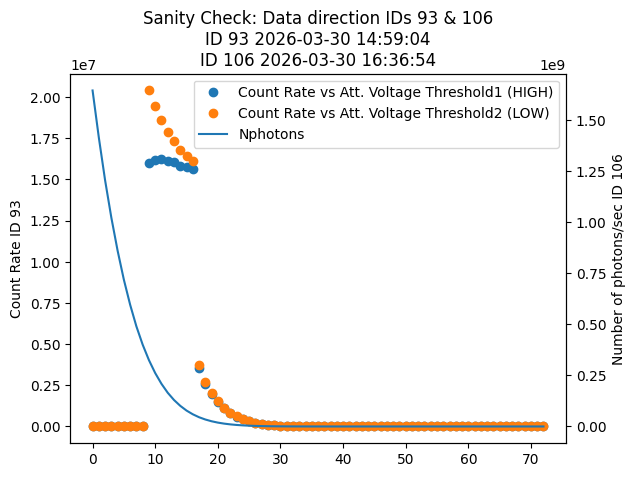

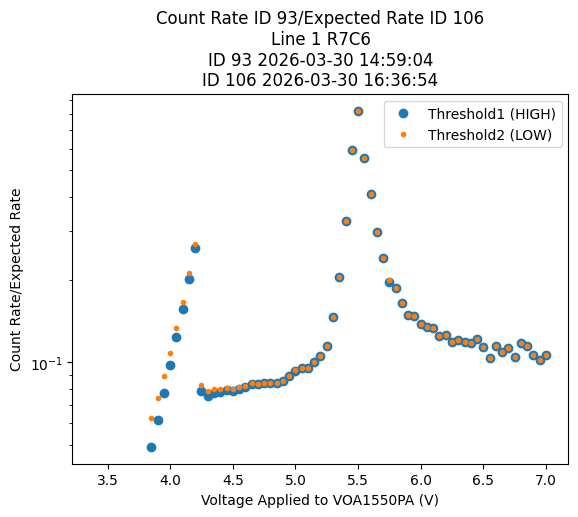

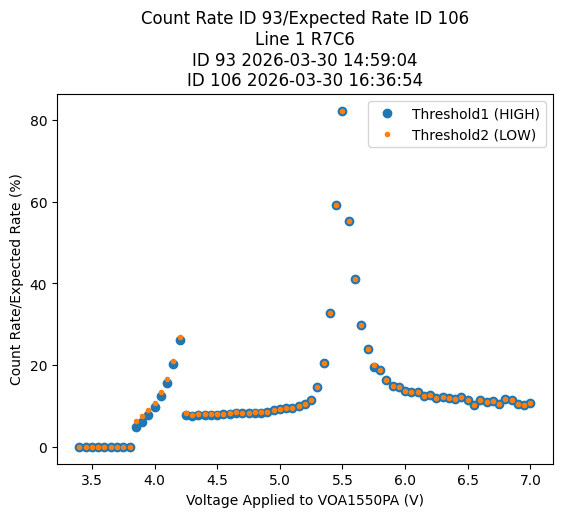

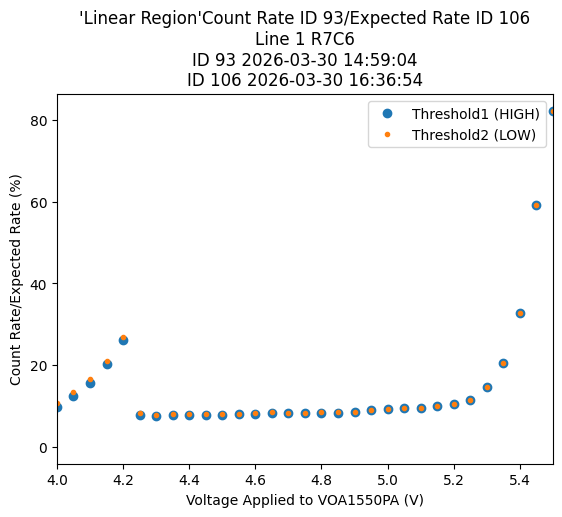

In [177]:
ID1 = 93

data = load_by_id(ID1).get_parameter_data()
# Reverse data to match low -> high attenuator voltages
CR1 = data['CR1']['CR1'][::-1] 
CR2 = data['CR2']['CR2'][::-1]
v_attenuator = data['v_attenuator']['v_attenuator'][::-1]
timestamp93 = load_by_id(ID1).run_timestamp()
device = load_by_id(ID1).metadata['device']
conditions = 'Box open, fibre input not shielded'

# ID 93 was swept high to low voltage - data needs to be flipped 


ID2 = 106
data2 = load_by_id(ID2).get_parameter_data()
v_attenuator2 = data2['v_attenuator']['v_attenuator']
timestamp106 = load_by_id(ID).run_timestamp()

# ID 106 was swept low to high voltages 


# Create figure and first axis
fig, ax1 = plt.subplots()
# First y-axis (left)
ax1.plot(CR1, 'o', label='Count Rate vs Att. Voltage Threshold1 (HIGH)')
ax1.plot(CR2, 'o', label='Count Rate vs Att. Voltage Threshold2 (LOW)')
ax1.set_ylabel(f'Count Rate ID {ID1}')
# Second y-axis (right)
ax2 = ax1.twinx()
ax2.plot(N_photons_ID106, label='Nphotons')
ax2.set_ylabel(f'Number of photons/sec ID {ID2}')
plt.title(f"Sanity Check: Data direction IDs {ID1} & {ID2}\nID 93 {timestamp93}\nID 106 {timestamp106}")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)



plt.figure()
plt.title(f'Count Rate ID {ID1}/Expected Rate ID {ID2}\n{device}\nID 93 {timestamp93}\nID 106 {timestamp106}')
plt.semilogy(v_attenuator, CR1/N_photons_ID106, 'o')
plt.semilogy(v_attenuator, CR2/N_photons_ID106, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate/Expected Rate')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')

plt.figure()
plt.title(f'Count Rate ID {ID1}/Expected Rate ID {ID2}\n{device}\nID 93 {timestamp93}\nID 106 {timestamp106}')
plt.plot(v_attenuator, 100*CR1/N_photons_ID106, 'o')
plt.plot(v_attenuator, 100*CR2/N_photons_ID106, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate/Expected Rate (%)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')


plt.figure()
plt.title(f'\'Linear Region\'Count Rate ID {ID1}/Expected Rate ID {ID2}\n{device}\nID 93 {timestamp93}\nID 106 {timestamp106}')
plt.plot(v_attenuator, 100*CR1/N_photons_ID106, 'o')
plt.plot(v_attenuator, 100*CR2/N_photons_ID106, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate/Expected Rate (%)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')
plt.xlim([4, 5.5])


In [125]:
idx = np.where(v_attenuator==5.0)[0][0]

In [126]:
N_photons_ID106[idx]

np.float64(6223.564471869121)

In [127]:
CR1[idx]

np.float64(27244.000435904)

In [129]:
100*CR1[idx]/N_photons_ID106[idx]

np.float64(437.75557494500924)

In [130]:
avg_attenuation[idx]

np.float64(69.1886934798532)

In [118]:
v_attenuator

array([3.4 , 3.45, 3.5 , 3.55, 3.6 , 3.65, 3.7 , 3.75, 3.8 , 3.85, 3.9 ,
       3.95, 4.  , 4.05, 4.1 , 4.15, 4.2 , 4.25, 4.3 , 4.35, 4.4 , 4.45,
       4.5 , 4.55, 4.6 , 4.65, 4.7 , 4.75, 4.8 , 4.85, 4.9 , 4.95, 5.  ,
       5.05, 5.1 , 5.15, 5.2 , 5.25, 5.3 , 5.35, 5.4 , 5.45, 5.5 , 5.55,
       5.6 , 5.65, 5.7 , 5.75, 5.8 , 5.85, 5.9 , 5.95, 6.  , 6.05, 6.1 ,
       6.15, 6.2 , 6.25, 6.3 , 6.35, 6.4 , 6.45, 6.5 , 6.55, 6.6 , 6.65,
       6.7 , 6.75, 6.8 , 6.85, 6.9 , 6.95, 7.  ])

In [115]:
avg_attenuation

array([11.4700991 , 12.12641544, 12.8210231 , 13.53740088, 14.28466848,
       15.06928939, 15.87963299, 16.73142324, 17.6051642 , 18.5143448 ,
       19.45563225, 20.43231552, 21.45431928, 22.5019122 , 23.58340591,
       24.7135051 , 25.8668565 , 27.07012097, 28.29270068, 29.55624068,
       30.85210473, 32.16704486, 33.52469438, 34.90047032, 36.30687925,
       37.75974699, 39.21496704, 40.74185511, 42.26367997, 43.8431574 ,
       45.49377776, 47.1861235 , 48.98365756, 50.83011058, 52.79271665,
       54.89796869, 57.1524128 , 59.66085879, 62.46142588, 65.5526037 ,
       69.18869348, 72.95277546, 74.96883136, 73.51168198, 71.62098408,
       69.91071346, 68.58015534, 67.62360414, 66.83257404, 66.26961401,
       65.77377263, 65.43073801, 65.08544636, 64.87306728, 64.63916532,
       64.45448842, 64.30520281, 64.15083475, 64.01434148, 63.87080836,
       63.78078322, 63.72626316, 63.63692388, 63.5663889 , 63.48470842,
       63.40441728, 63.39512923, 63.35018432, 63.26999812, 63.21

(0.0, 5e-06)

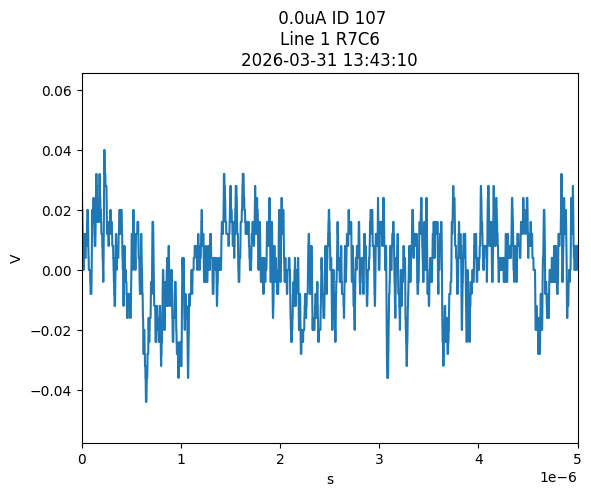

In [182]:
ID = 107
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']
timestamp = load_by_id(ID).run_timestamp()
device = load_by_id(ID).metadata['device']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {ID}\n{device}\n{timestamp}')
plt.xlabel('s')
plt.ylabel('V')
plt.xlim([0, 5e-6])

Text(0, 0.5, 'V')

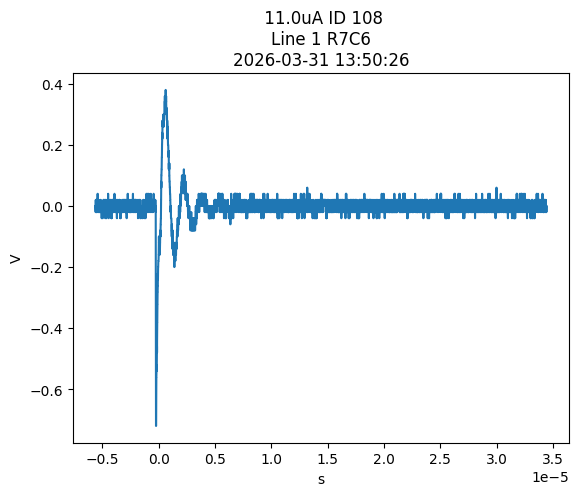

In [184]:
ID = 108
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']
timestamp = load_by_id(ID).run_timestamp()
device = load_by_id(ID).metadata['device']


plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {ID}\n{device}\n{timestamp}')
plt.xlabel('s')
plt.ylabel('V')


Text(0, 0.5, 'V')

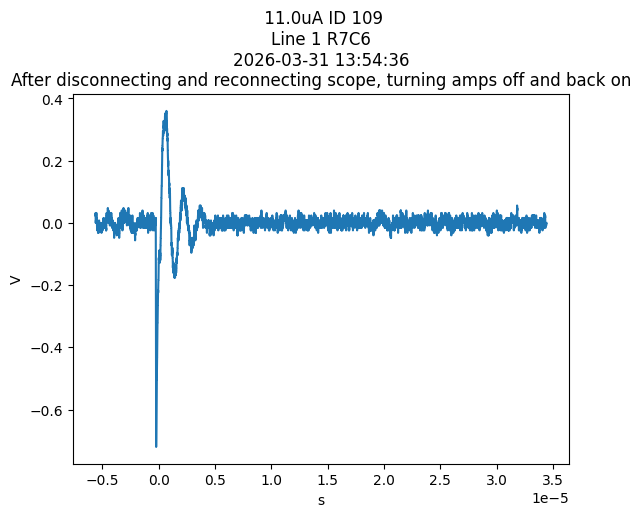

In [186]:
ID = 109
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']
timestamp = load_by_id(ID).run_timestamp()
device = load_by_id(ID).metadata['device']
conditions = 'After disconnecting and reconnecting scope, turning amps off and back on'


plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {ID}\n{device}\n{timestamp}\n{conditions}')
plt.xlabel('s')
plt.ylabel('V')


Text(0, 0.5, 'V')

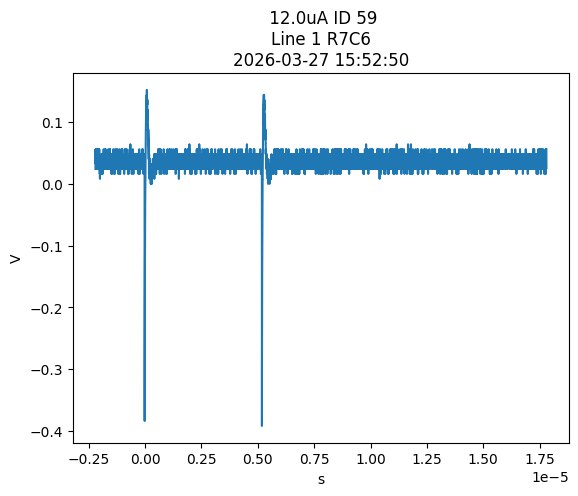

In [194]:
ID = 59
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']
timestamp = load_by_id(ID).run_timestamp()
# device = load_by_id(ID).metadata['device']

plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {ID}\n{device}\n{timestamp}')
plt.xlabel('s')
plt.ylabel('V')


(-1e-06, 2.5e-06)

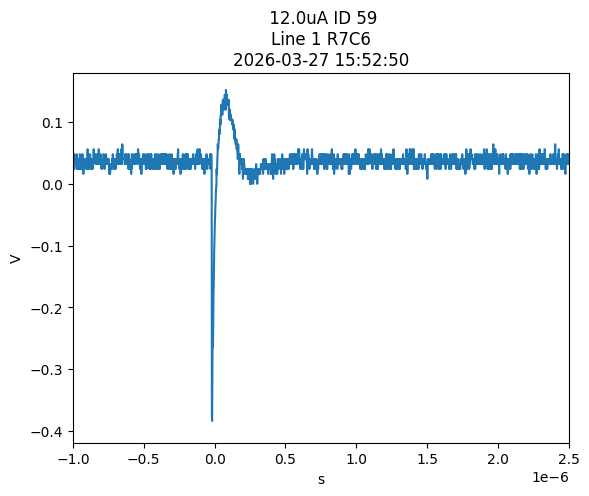

In [193]:
ID = 59
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']
timestamp = load_by_id(ID).run_timestamp()
# device = load_by_id(ID).metadata['device']


plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {ID}\n{device}\n{timestamp}')
plt.xlabel('s')
plt.ylabel('V')
plt.xlim([-0.1e-5, 0.25e-5])


(-1e-06, 2.5e-06)

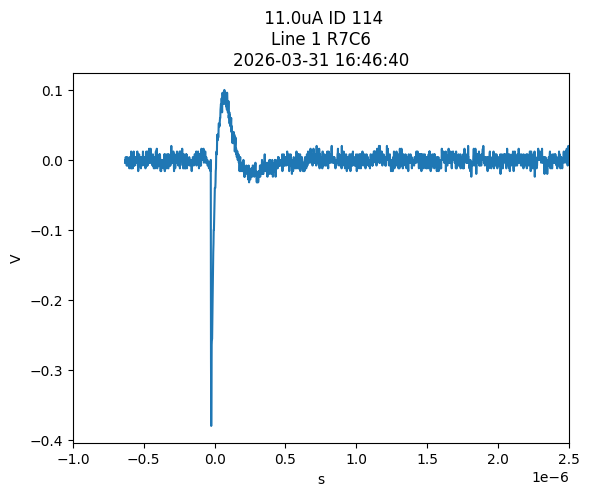

In [196]:
ID = 114
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']
timestamp = load_by_id(ID).run_timestamp()
# device = load_by_id(ID).metadata['device']


plt.plot(time_axis, trace)
plt.title(f' {current*1e6}uA ID {ID}\n{device}\n{timestamp}')
plt.xlabel('s')
plt.ylabel('V')
plt.xlim([-0.1e-5, 0.25e-5])


Attenuator calibration

69.68495125854487


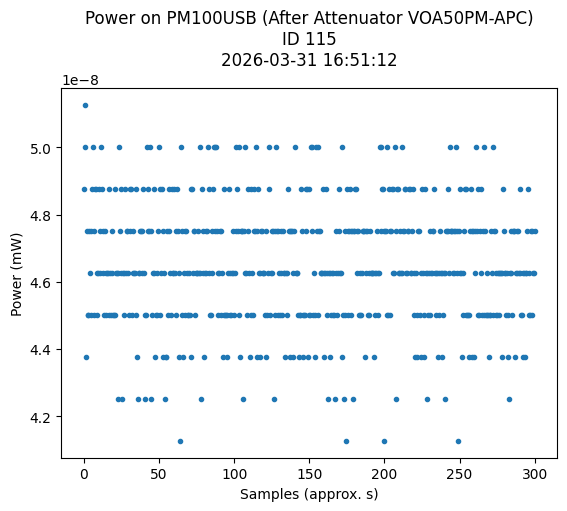

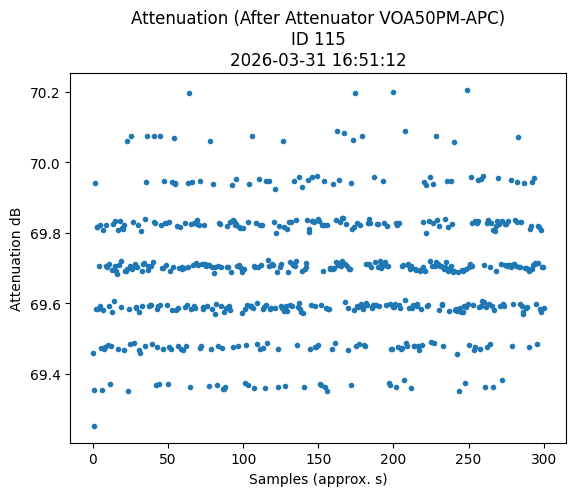

In [208]:
ID = 115
data = load_by_id(ID).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']
device = 'VOA50PM-APC'
timestamp = load_by_id(ID).run_timestamp()

plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title(f'Power on PM100USB (After Attenuator {device})\nID {ID}\n{timestamp}')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title(f'Attenuation (After Attenuator {device})\nID {ID}\n{timestamp}')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')

avg_attenuationID115 = np.average(attenuation)

print(avg_attenuationID115)


69.69309632411775


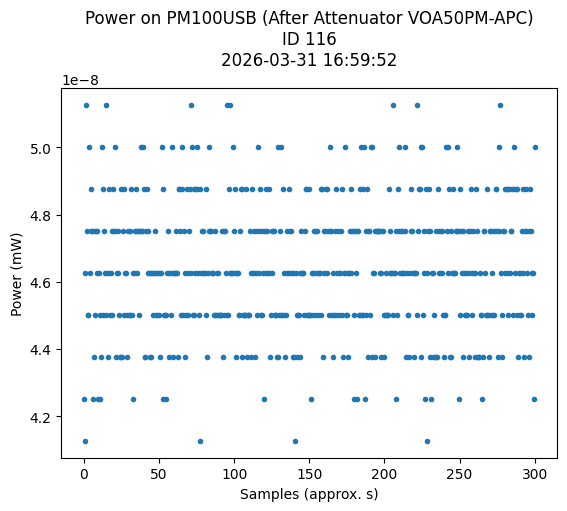

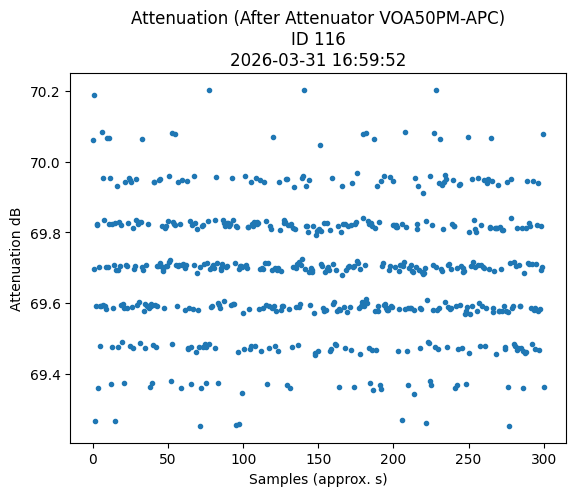

In [204]:
ID = 116
data = load_by_id(ID).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']
device = 'VOA50PM-APC'
timestamp = load_by_id(ID).run_timestamp()


plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title(f'Power on PM100USB (After Attenuator {device})\nID {ID}\n{timestamp}')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title(f'Attenuation (After Attenuator {device})\nID {ID}\n{timestamp}')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')


print(np.average(attenuation))


# 1/4/26

(-0.15, 0.15)

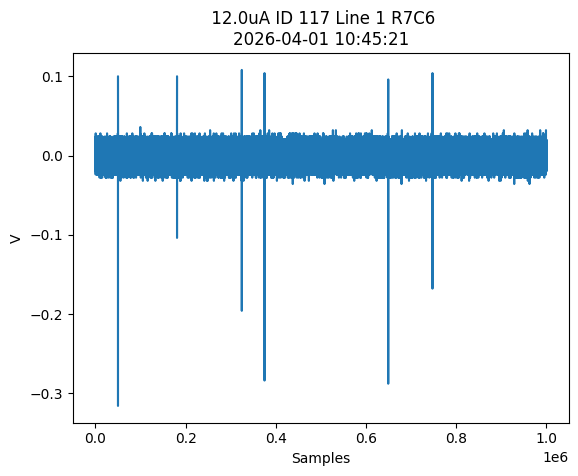

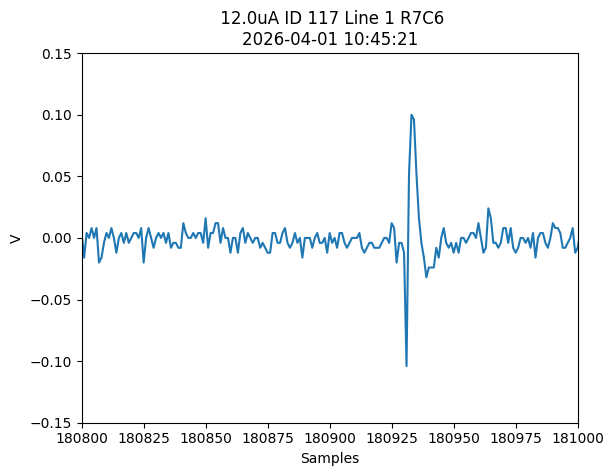

In [206]:
ID = 117
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']
device = device_name_1
timestamp = load_by_id(ID).run_timestamp()

plt.figure()
plt.plot(trace)
plt.title(f' {current*1e6}uA ID {ID} {device}\n{timestamp}')
plt.xlabel('Samples')
plt.ylabel('V')

plt.figure()
plt.plot(trace)
plt.title(f' {current*1e6}uA ID {ID} {device}\n{timestamp}')
plt.xlabel('Samples')
plt.ylabel('V')
plt.xlim([180.8e3, 181e3])
plt.ylim([-0.15, 0.15])

Text(0.5, 0, 'Voltage Applied to VOA1550PA (V)')

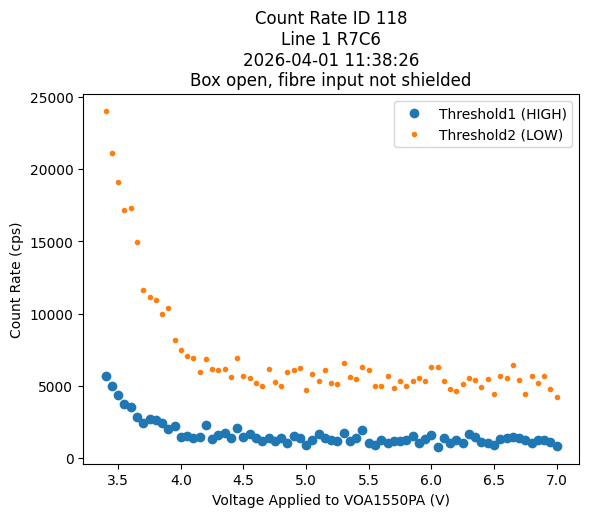

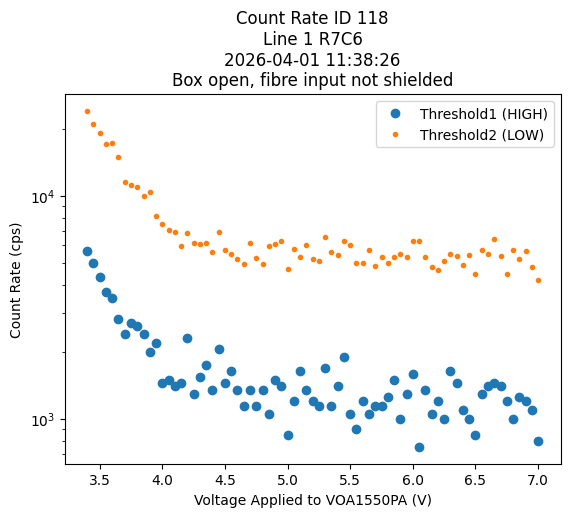

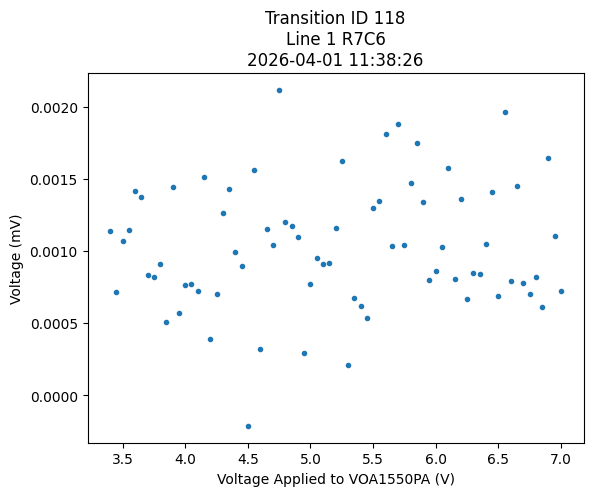

In [226]:
ID = 118

data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
v_attenuator = data['v_attenuator']['v_attenuator']
timestamp = load_by_id(ID).run_timestamp()
device = load_by_id(ID).metadata['device']
conditions = 'Box open, fibre input not shielded'

plt.title(f'Count Rate ID {ID}\n{device}\n{timestamp}\n{conditions}')
plt.plot(v_attenuator, CR1, 'o')
plt.plot(v_attenuator, CR2, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (cps)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')

plt.figure()
plt.title(f'Count Rate ID {ID}\n{device}\n{timestamp}\n{conditions}')
plt.semilogy(v_attenuator, CR1, 'o')
plt.semilogy(v_attenuator, CR2, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (cps)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')


plt.figure()
plt.title(f'Transition ID {ID}\n{device}\n{timestamp}')
plt.plot(v_attenuator, voltage*1e3, '.')
plt.ylabel('Voltage (mV)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')



Re-calculate the attenuation curve with the adjusted value for Patt_VOA50PM_APC

In [209]:
avg_attenuationID115

np.float64(69.68495125854487)

Text(0, 0.5, 'log(Power (W))')

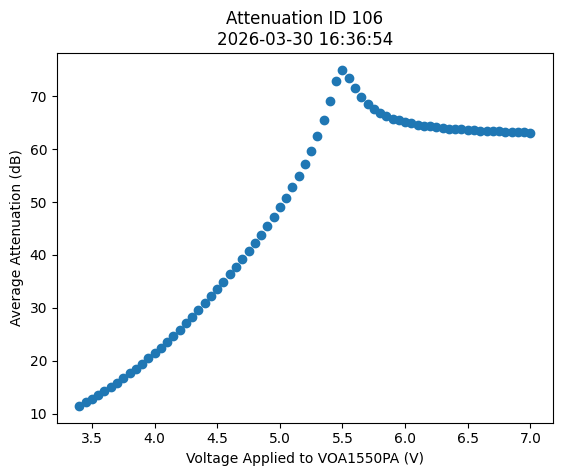

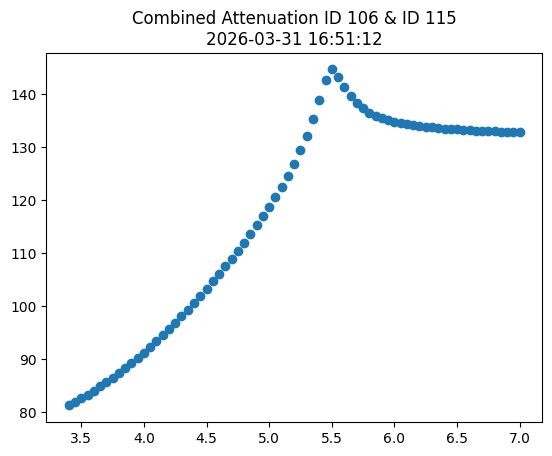

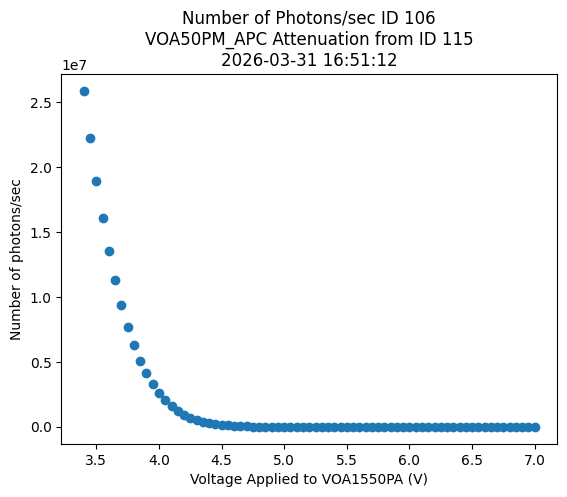

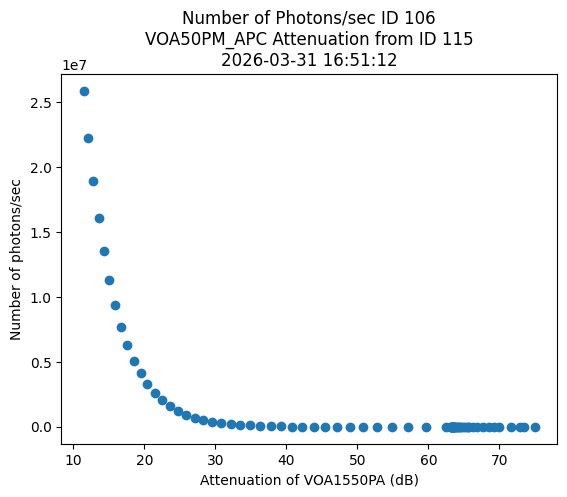

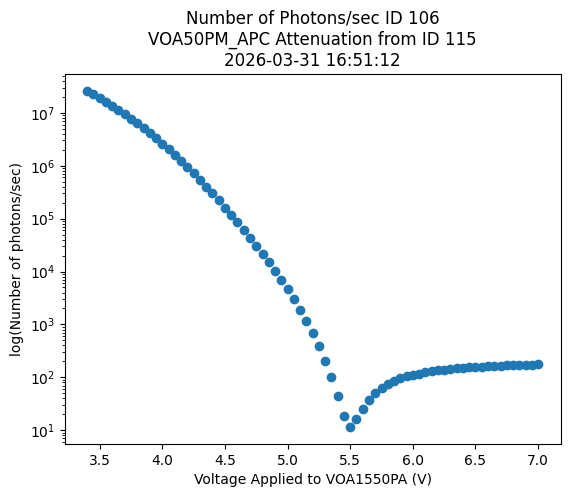

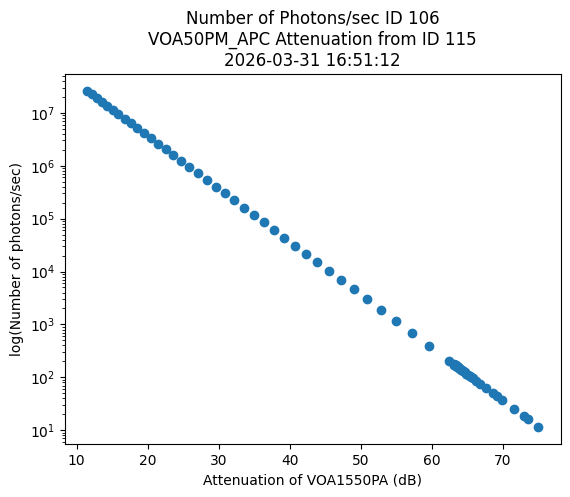

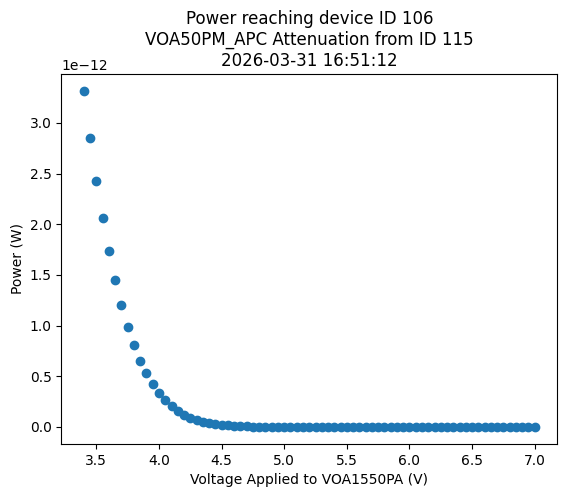

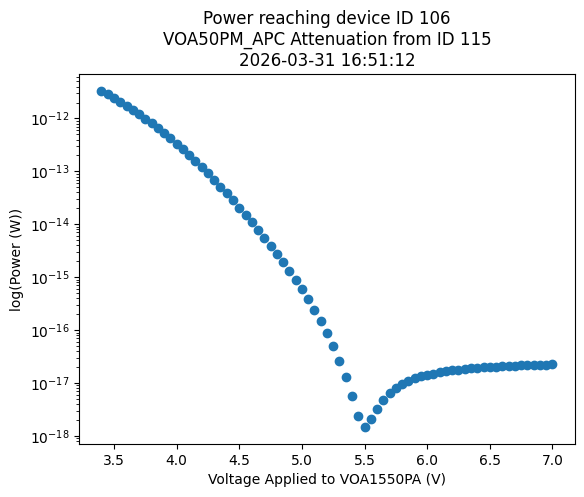

In [215]:
IDVOA_APC = 115
timestamp115 = load_by_id(IDVOA_APC).run_timestamp()

ID = 106
data = load_by_id(ID).get_parameter_data()
v_attenuator = data['v_attenuator']['v_attenuator']
avg_attenuation = data['avg_attenuation']['avg_attenuation']
timestamp = load_by_id(ID).run_timestamp()

plt.title(f'Attenuation ID {ID}\n{timestamp}')
plt.plot(v_attenuator, avg_attenuation, 'o')
plt.ylabel('Average Attenuation (dB)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')

plt.figure()
plt.title(f'Combined Attenuation ID {ID} & ID {115}\n{timestamp115}')
plt.plot(v_attenuator, avg_attenuation+avg_attenuationID115, 'o')


import scipy.constants as spc 
wavelength = 1550e-9 
f = spc.c/wavelength 
Ephoton = spc.h*f

N_photons_ID106_ID115 = []
Pdevice_ID106_ID115 = []

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265 # From measuremnet 3 beam splitter calibration 

Plaser = 0.00447186176/bs90 # < from run ID 118 
# Plaser =  0.0045/bs90 # <- reduce laser power
# Plaser =  0.004/bs90 # <- reduce laser power
Pin = Plaser*bs10 # power reaching attenuators 

for attenuation in avg_attenuation: # go through values measured for average attenuation

    Patt_VOA1550PA = -attenuation
    Patt_VOA50PM_APC = -avg_attenuationID115 # ID 115, average calculated


    total_attenuation_fiber2 = Patt_VOA1550PA + Patt_VOA50PM_APC
    Pdevice = Pin*(10**(total_attenuation_fiber2/10))
    
    # dBattenuation = 10*log10(Pout/Pin)

    N_photons_ID106_ID115.append(Pdevice/Ephoton)
    Pdevice_ID106_ID115.append(Pdevice)


plt.figure()
plt.title(f'Number of Photons/sec ID {ID}\nVOA50PM_APC Attenuation from ID {IDVOA_APC}\n{timestamp115}')
plt.plot(v_attenuator, N_photons_ID106_ID115, 'o')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')
plt.ylabel('Number of photons/sec')

plt.figure()
plt.title(f'Number of Photons/sec ID {ID}\nVOA50PM_APC Attenuation from ID {IDVOA_APC}\n{timestamp115}')
plt.plot(avg_attenuation, N_photons_ID106_ID115, 'o')
plt.xlabel(r'Attenuation of VOA1550PA (dB)')
plt.ylabel('Number of photons/sec')

plt.figure()
plt.title(f'Number of Photons/sec ID {ID}\nVOA50PM_APC Attenuation from ID {IDVOA_APC}\n{timestamp115}')
plt.semilogy(v_attenuator, N_photons_ID106_ID115, 'o')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')
plt.ylabel('log(Number of photons/sec)')

plt.figure()
plt.title(f'Number of Photons/sec ID {ID}\nVOA50PM_APC Attenuation from ID {IDVOA_APC}\n{timestamp115}')
plt.semilogy(avg_attenuation, N_photons_ID106_ID115, 'o')
plt.xlabel(r'Attenuation of VOA1550PA (dB)')
plt.ylabel('log(Number of photons/sec)')


plt.figure()
plt.title(f'Power reaching device ID {ID}\nVOA50PM_APC Attenuation from ID {IDVOA_APC}\n{timestamp115}')
plt.plot(v_attenuator, Pdevice_ID106_ID115, 'o')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')
plt.ylabel('Power (W)')

plt.figure()
plt.title(f'Power reaching device ID {ID}\nVOA50PM_APC Attenuation from ID {IDVOA_APC}\n{timestamp115}')
plt.semilogy(v_attenuator, Pdevice_ID106_ID115, 'o')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')
plt.ylabel('log(Power (W))')


(-1.0, 1.2)

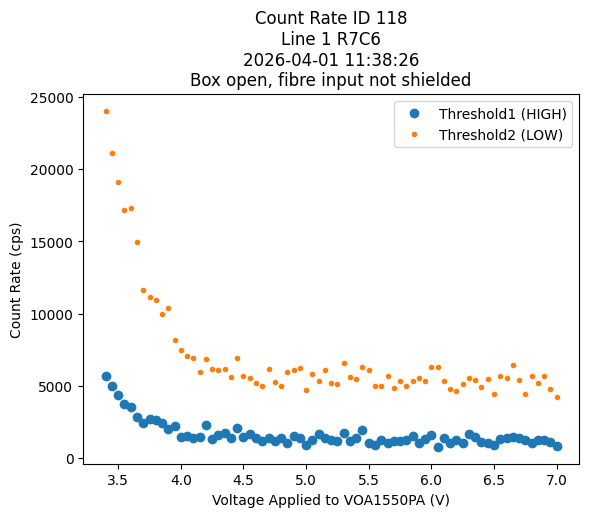

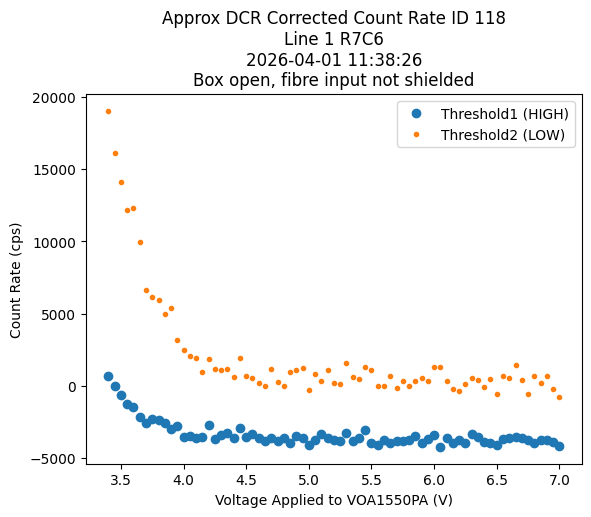

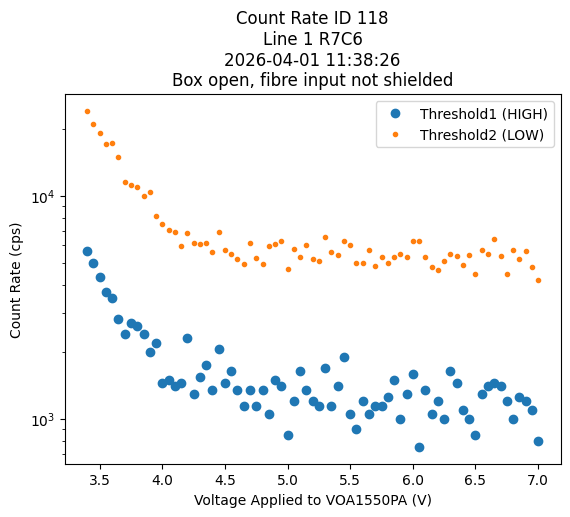

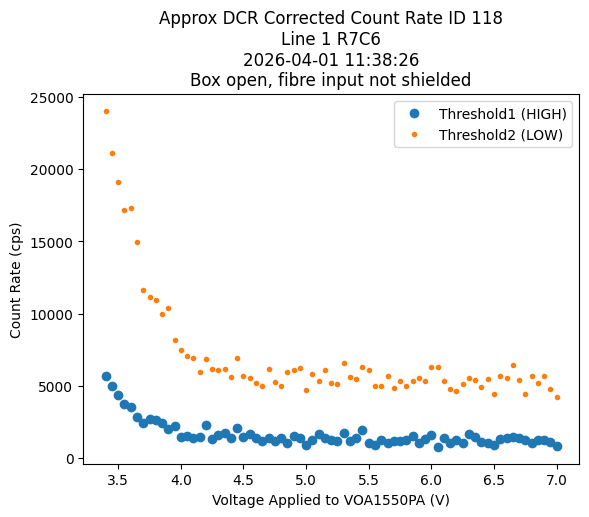

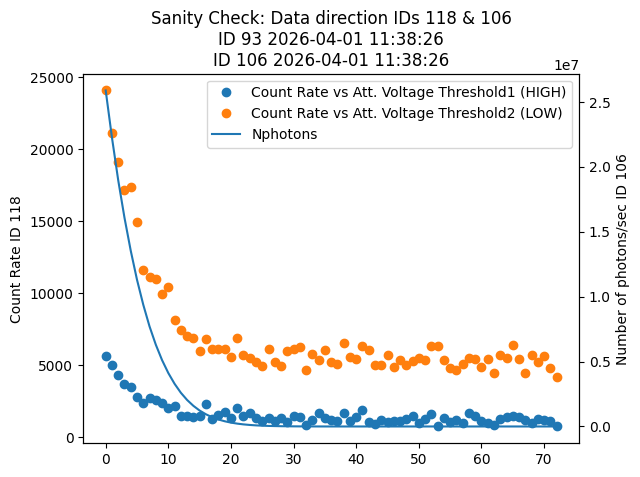

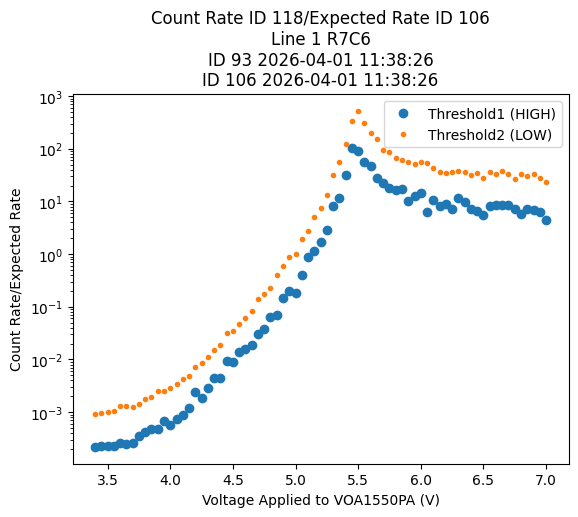

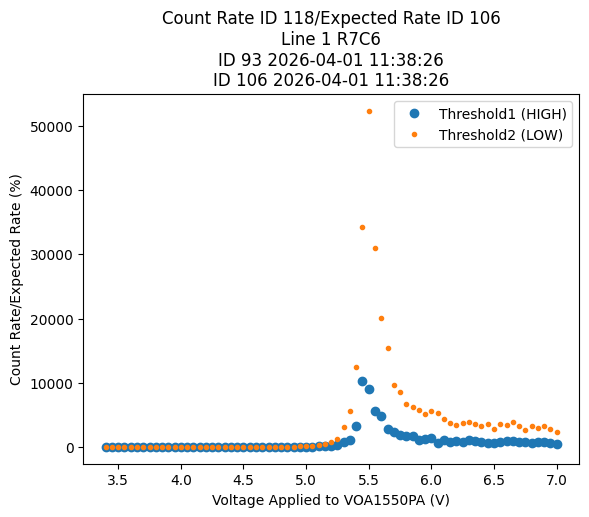

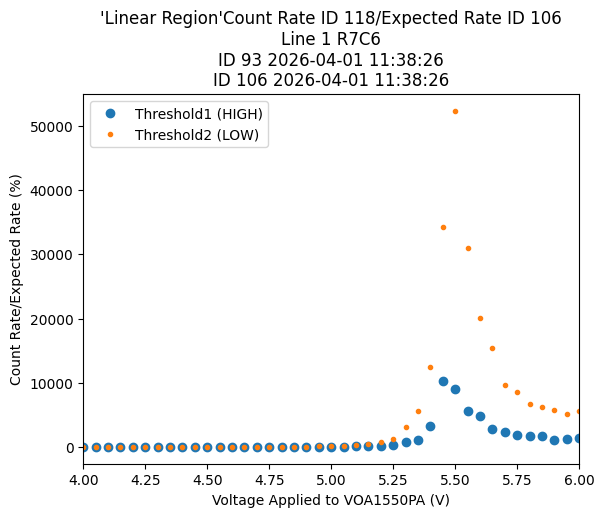

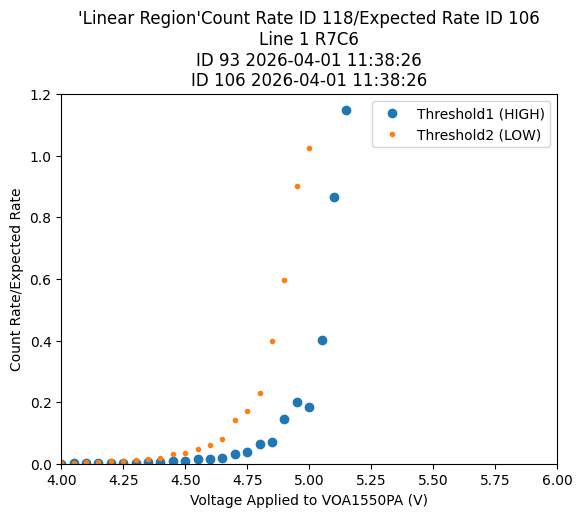

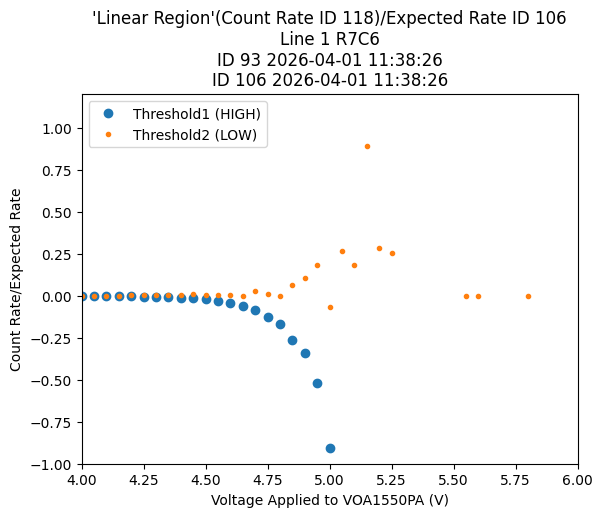

In [234]:
N_photons = N_photons_ID106_ID115

ID1 = 118

data = load_by_id(ID1).get_parameter_data()
# Reverse data to match low -> high attenuator voltages
CR1 = data['CR1']['CR1'][::-1] 
CR2 = data['CR2']['CR2'][::-1]
v_attenuator = data['v_attenuator']['v_attenuator'][::-1]
timestamp1 = load_by_id(ID1).run_timestamp()
device = load_by_id(ID1).metadata['device']
conditions = 'Box open, fibre input not shielded'

# ID 93 was swept high to low voltage - data needs to be flipped 


ID2 = 106
data2 = load_by_id(ID2).get_parameter_data()
v_attenuator2 = data2['v_attenuator']['v_attenuator']
timestamp106 = load_by_id(ID).run_timestamp()

DCR_approx = 5e3


plt.figure()
plt.title(f'Count Rate ID {ID1}\n{device}\n{timestamp1}\n{conditions}')
plt.plot(v_attenuator, CR1, 'o')
plt.plot(v_attenuator, CR2, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (cps)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')

plt.figure()
plt.title(f'Approx DCR Corrected Count Rate ID {ID1}\n{device}\n{timestamp1}\n{conditions}')
plt.plot(v_attenuator, CR1-DCR_approx, 'o')
plt.plot(v_attenuator, CR2-DCR_approx, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (cps)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')

plt.figure()
plt.title(f'Count Rate ID {ID1}\n{device}\n{timestamp1}\n{conditions}')
plt.semilogy(v_attenuator, CR1, 'o')
plt.semilogy(v_attenuator, CR2, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (cps)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')

plt.figure()
plt.title(f'Approx DCR Corrected Count Rate ID {ID1}\n{device}\n{timestamp1}\n{conditions}')
plt.plot(v_attenuator, CR1, 'o')
plt.plot(v_attenuator, CR2, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate (cps)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')


# Create figure and first axis
fig, ax1 = plt.subplots()
# First y-axis (left)
ax1.plot(CR1, 'o', label='Count Rate vs Att. Voltage Threshold1 (HIGH)')
ax1.plot(CR2, 'o', label='Count Rate vs Att. Voltage Threshold2 (LOW)')
ax1.set_ylabel(f'Count Rate ID {ID1}')
# Second y-axis (right)
ax2 = ax1.twinx()
ax2.plot(N_photons_ID106_ID115, label='Nphotons')
ax2.set_ylabel(f'Number of photons/sec ID {ID2}')
plt.title(f"Sanity Check: Data direction IDs {ID1} & {ID2}\nID 93 {timestamp93}\nID 106 {timestamp106}")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)



plt.figure()
plt.title(f'Count Rate ID {ID1}/Expected Rate ID {ID2}\n{device}\nID 93 {timestamp93}\nID 106 {timestamp106}')
plt.semilogy(v_attenuator, CR1/N_photons_ID106_ID115, 'o')
plt.semilogy(v_attenuator, CR2/N_photons_ID106_ID115, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate/Expected Rate')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')

plt.figure()
plt.title(f'Count Rate ID {ID1}/Expected Rate ID {ID2}\n{device}\nID 93 {timestamp93}\nID 106 {timestamp106}')
plt.plot(v_attenuator, 100*CR1/N_photons_ID106_ID115, 'o')
plt.plot(v_attenuator, 100*CR2/N_photons_ID106_ID115, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate/Expected Rate (%)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')


plt.figure()
plt.title(f'\'Linear Region\'Count Rate ID {ID1}/Expected Rate ID {ID2}\n{device}\nID 93 {timestamp93}\nID 106 {timestamp106}')
plt.plot(v_attenuator, 100*CR1/N_photons_ID106_ID115, 'o')
plt.plot(v_attenuator, 100*CR2/N_photons_ID106_ID115, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate/Expected Rate (%)')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')
plt.xlim([4, 6])


plt.figure()
plt.title(f'\'Linear Region\'Count Rate ID {ID1}/Expected Rate ID {ID2}\n{device}\nID 93 {timestamp93}\nID 106 {timestamp106}')
plt.plot(v_attenuator, CR1/N_photons_ID106_ID115, 'o')
plt.plot(v_attenuator, CR2/N_photons_ID106_ID115, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate/Expected Rate')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')
plt.xlim([4, 6])
plt.ylim([0, 1.2])



plt.figure()
plt.title(f'\'Linear Region\'(Count Rate ID {ID1})/Expected Rate ID {ID2}\n{device}\nID 93 {timestamp93}\nID 106 {timestamp106}')
plt.plot(v_attenuator, (CR1-DCR_approx)/N_photons_ID106_ID115, 'o')
plt.plot(v_attenuator, (CR2-DCR_approx)/N_photons_ID106_ID115, '.')
plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
plt.ylabel('Count Rate/Expected Rate')
plt.xlabel(r'Voltage Applied to VOA1550PA (V)')
plt.xlim([4, 6])
plt.ylim([-1, 1.2])


Check dark counts for 12uA, exact current conditions